#  Gelismis Fiyat Tahminleme: Gradient Boosting & Clustering Hibrit

Bu proje, yuksek performansli bir regresyon pipeline'i kurar. Sadece model egitmiyoruz; verideki gizli desenleri yakalamak icin Denetimsiz Ogrenme (Clustering) kullanarak ozellik muhendisligi yapiyoruz.

**Ogrenci :** Ramazan Bozkurt  
**Proje :** Arac Fiyat Tahmin 
**Ogrenci No :** 22040301027  

In [2]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.neighbors import KNeighborsClassifier
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# Gorsellestirme Ayarlari
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

## 1. Motor: Sizintisiz Kumeleme (Leakage-Free Clustering)

Standart kumeleme, uretim asamasinda basarisiz olur cunku yeni veriyi egitmeden taniyamaz. Burada ozel bir Transformer sinifi tanimliyoruz:
1. Kumeleri saddece egitim verisinde ogrenir.
2. AgglomerativeClustering icin KNN kullanarak tahmin yetenegi kazandirir.
3. Sifir veri sizintisi (zero leakage) garanti eder.

In [3]:
class ClusterFeatureExtractor(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=6, strategy='kmeans'):
        self.n_clusters = n_clusters
        self.strategy = strategy
        self.clusterer = None
        self.knn = None

    def fit(self, X, y=None):
        # Verini yapısını sadece eğitim setinden öğrenmesini sağlıyoruz
        if self.strategy == 'kmeans':
            self.clusterer = KMeans(n_clusters=self.n_clusters, random_state=42, n_init=10)
            self.clusterer.fit(X)
        else: # Agglomerative
            self.clusterer = AgglomerativeClustering(n_clusters=self.n_clusters)
            labels = self.clusterer.fit_predict(X)
            # Agglomerative kumelerinin seklini 'ogrenmek' icin KNN kullanıyoruz
            self.knn = KNeighborsClassifier(n_neighbors=1)
            self.knn.fit(X, labels)
        return self

    def transform(self, X):
        if self.strategy == 'kmeans':
            clusters = self.clusterer.predict(X)
        else:
            clusters = self.knn.predict(X)
        # OneHotEncoder'in bunu Sayi degil Kategori olarak gormesi icin string donduruyoruz
        return clusters.reshape(-1, 1).astype(str)

## 2. Veri Hazirligi & Hedef Analizi
Modele veriyi vermeden once, neyi tahmin ettigimize bakalim. Fiyatlar genelde *Power Law* dagilimi izler, bu yuzden Log Donusumu yaparak veriyi "Normallestirmemiz" gerekir.

In [4]:
# Veriyi Yukluyoruz
try:
    df = pd.read_csv('cleaned_data.csv')
    print(f"-> Veri Basariyla Yuklendi. Boyut: {df.shape}")
except FileNotFoundError:
    print("HATA: 'cleaned_data.csv' bulunamadi.")

# Ozellikleri Tanimliyoruz
numeric_features = ['mileage', 'tax', 'mpg', 'engine_size', 'car_age']
categorical_features = ['marka', 'model', 'transmission', 'fuel_type']

# X ve y değerleri hazırlıyoruz
X = df.drop('price', axis=1)
y_raw = df['price']
y = np.log1p(y_raw)

# Veriyi Bol bu tutarlilik icin onemli bir adim
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("-> Egitim/Test Ayrimi Tamamlandi.")

-> Veri Basariyla Yuklendi. Boyut: (29965, 11)
-> Egitim/Test Ayrimi Tamamlandi.


###  Grafik 1: Neden Log Donusumu?
Orijinal fiyat dagilimi ile log donusumu yapilmis hali karsilastiralim.

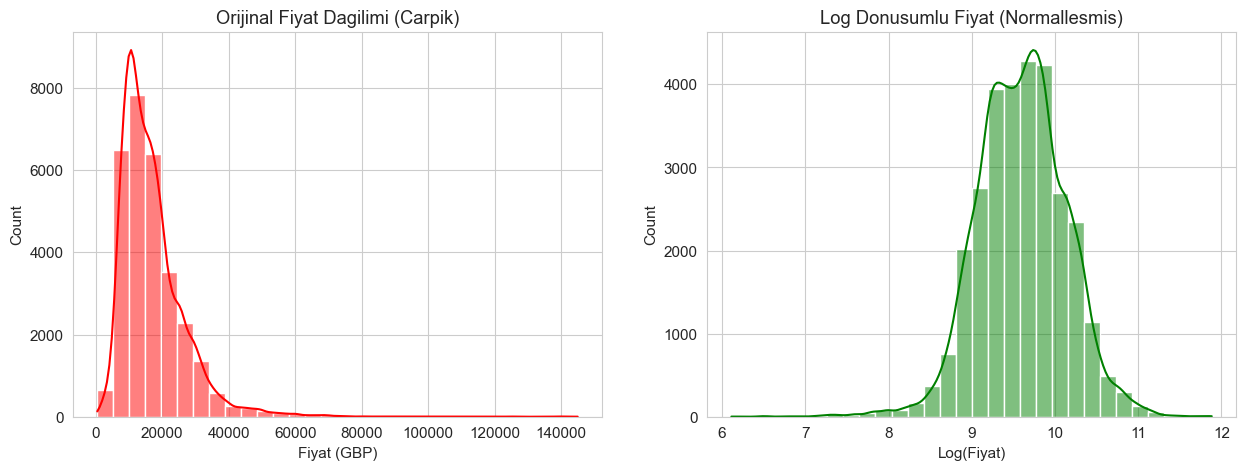

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Orijinal Fiyat
sns.histplot(y_raw, kde=True, ax=ax[0], color='red', bins=30)
ax[0].set_title('Orijinal Fiyat Dagilimi (Carpik)')
ax[0].set_xlabel('Fiyat (GBP)')

# Log Fiyat
sns.histplot(y, kde=True, ax=ax[1], color='green', bins=30)
ax[1].set_title('Log Donusumlu Fiyat (Normallesmis)')
ax[1].set_xlabel('Log(Fiyat)')

plt.show()

## 3. Pipeline Mimarisi Kurulumu
Clustering'i acip kapatabilekn dinamik bir pipeline kuruyoruz. Gradient Boosting ile uyumluluk sorunu yasamamak icin sparse_output=False kullandik

In [7]:
def get_pipeline(strategy=None):
    # Sayisal Islemler
    num_pipe = Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('std', StandardScaler())
    ])
    
    # Kategorik Islemler
    cat_pipe = Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])

    # Temel Donusturuculer
    transformers = [
        ('num', num_pipe, numeric_features),
        ('cat', cat_pipe, categorical_features)
    ]
    
    # Eger strateji secilmisse Kumeleme ekler
    if strategy:
        cluster_feature_pipe = Pipeline([
            ('num_prep', num_pipe),
            ('extractor', ClusterFeatureExtractor(n_clusters=6, strategy=strategy)),
            ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ])
        transformers.append(('clusters', cluster_feature_pipe, numeric_features))

    preprocessor = ColumnTransformer(transformers=transformers)

    # Regresor
    return Pipeline([
        ('prep', preprocessor),
        ('reg', GradientBoostingRegressor(n_estimators=500, learning_rate=0.1, max_depth=6, random_state=42))
    ])

## 4. Calistirma & Karsilastirma
Uc senaryoyu kosturacagiz:
1.  **Standart GBR:** Saf Regresyon.
2.  **GBR + KMeans:** Bolumleme tabanli kumeleme ozellikleri.
3.  **GBR + Agglomerative:** Hiyerarsik tabanli kumeleme ozellikleri.

In [8]:
results = []
predictions = {} # Cizim icin tahminleri saklayacagimiz degisken
modes = [None, 'kmeans', 'agglomerative']

print("Egitim Dongusu Basliyor...")

for mode in modes:
    start_time = time.time()
    
    name = "Standart GBR" if mode is None else f"GBR + {mode.capitalize()}"
    print(f"-> Egitim: {name}...")
    
    # Modeli Kur & Egit
    pipe = get_pipeline(strategy=mode)
    pipe.fit(X_train, y_train)
    
    # Tahmin Et
    y_pred_log = pipe.predict(X_test)
    predictions[name] = y_pred_log
    
    # Metrikleri Hesapla (Gercek Fiyatlar icin Ters Log)
    y_test_orig = np.expm1(y_test)
    y_pred_orig = np.expm1(y_pred_log)
    
    mae = mean_absolute_error(y_test_orig, y_pred_orig)
    rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
    r2 = r2_score(y_test, y_pred_log)
    
    exec_time = time.time() - start_time
    
    results.append({
        'Senaryo': name,
        'R2 Skoru': r2,
        'MAE (GBP)': mae,
        'RMSE (GBP)': rmse,
        'Sure (s)': exec_time
    })

results_df = pd.DataFrame(results)
print("\nIslem Tamam.")

Egitim Dongusu Basliyor...
-> Egitim: Standart GBR...
-> Egitim: GBR + Kmeans...
-> Egitim: GBR + Agglomerative...

Islem Tamam.


###  Grafik 2: Skor Tablosu
Hangi modelin R2 Skoru (Basari Puani) acisindan en iyi olduguna bakalim. Yuksek olmasi daha iyidir.

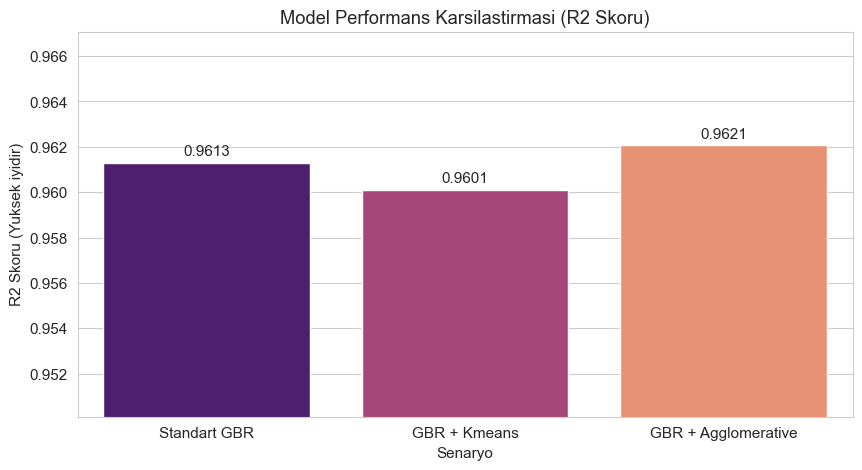

In [13]:
plt.figure(figsize=(10, 5))
ax = sns.barplot(x='Senaryo', y='R2 Skoru', data=results_df, palette='magma', hue='Senaryo', legend=False)
plt.ylim(results_df['R2 Skoru'].min() - 0.01, results_df['R2 Skoru'].max() + 0.005)
plt.title('Model Performans Karsilastirmasi (R2 Skoru)')
plt.ylabel('R2 Skoru (Yuksek iyidir)')

# Cubuklarin uzerine degerleri yaz
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=3)

plt.show()

###  Grafik 3: Gercek vs Tahmin (En Iyi Model)
En iyi modeli secip, noktalarin (tahminler) kirmizi cizgiye (mukemmel tahmin) ne kadar yakin olduguna bakiyoruz.

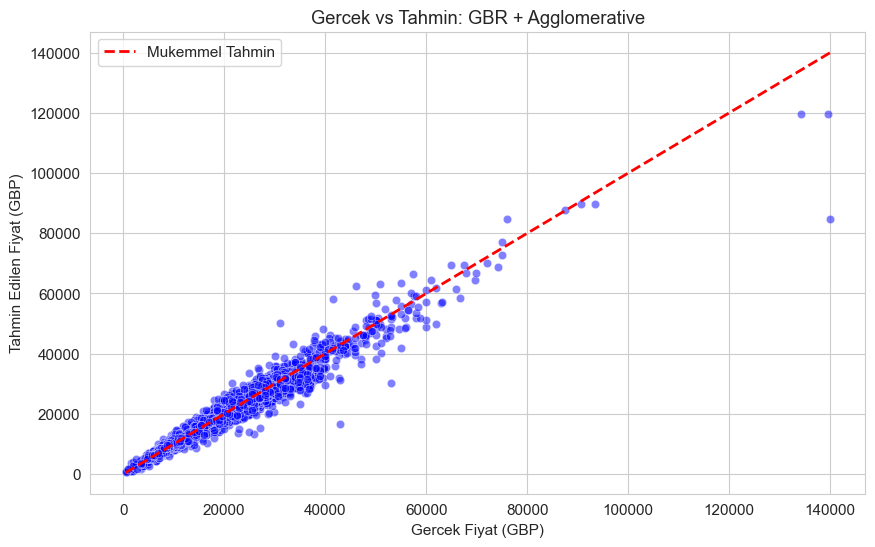

In [14]:
# En iyi modeli bul
best_model_name = results_df.sort_values(by='R2 Skoru', ascending=False).iloc[0]['Senaryo']
best_preds_log = predictions[best_model_name]

y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(best_preds_log)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_real, y=y_pred_real, alpha=0.5, color='blue')

# Ideal Cizgi (Mukemmel Tahmin)
min_val = min(y_test_real.min(), y_pred_real.min())
max_val = max(y_test_real.max(), y_pred_real.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Mukemmel Tahmin')

plt.title(f'Gercek vs Tahmin: {best_model_name}')
plt.xlabel('Gercek Fiyat (GBP)')
plt.ylabel('Tahmin Edilen Fiyat (GBP)')
plt.legend()
plt.show()

###  Grafik 4: Artik (Residual) Analizi
Hatalar rastgele mi? Yoksa bir desen var mi? Sifir etrafinda rastgele dagilmis bir bulut gormek istiyoruz.
* **Pozitif Deger:** Tahminimiz cok dusuk kalmis.
* **Negatif Deger:** Tahminimiz cok yuksek cikmis.

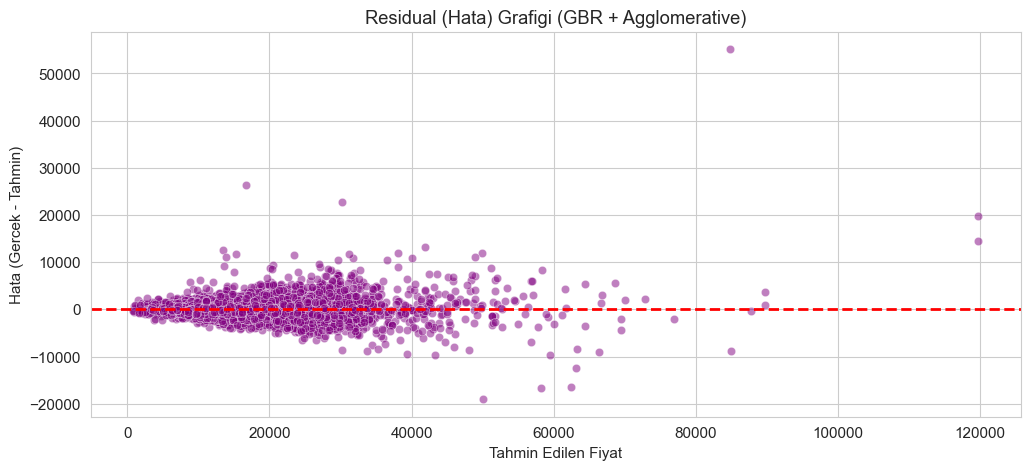

In [15]:
residuals = y_test_real - y_pred_real

plt.figure(figsize=(12, 5))
sns.scatterplot(x=y_pred_real, y=residuals, alpha=0.5, color='purple')
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.title(f'Residual (Hata) Grafigi ({best_model_name})')
plt.xlabel('Tahmin Edilen Fiyat')
plt.ylabel('Hata (Gercek - Tahmin)')
plt.show()

## Final Sonuclar Tablosu
Deneyin detayli dokumu asagidadir.

In [16]:
print("="*80)
print(f"{'FINAL PERFORMANS RAPORU':^80}")
print("="*80)
print(results_df.to_string(index=False))
print("="*80)

                            FINAL PERFORMANS RAPORU                             
            Senaryo  R2 Skoru   MAE (GBP)  RMSE (GBP)   Sure (s)
       Standart GBR  0.961287 1273.039862 2088.298615 142.967757
       GBR + Kmeans  0.960107 1295.546305 2173.510019 154.552916
GBR + Agglomerative  0.962074 1275.154370 2089.603602 178.937660
